## Importing Libraries

In [1]:
import os
import pickle
import numpy as np
from tqdm.notebook import tqdm

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

2026-04-01 13:11:17.439020: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775049077.625816      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775049077.677323      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775049078.103881      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775049078.103928      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775049078.103931      23 computation_placer.cc:177] computation placer alr

In [2]:
BASE_DIR = '/kaggle/input/datasets/farhanabbas2004/dataset'
WORKING_DIR = '/kaggle/working/'

## Extracating image features

    

In [3]:
model = VGG16()
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)
print(model.summary())

I0000 00:00:1775049098.033327      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,260,544 (512.16 MB)

 Trainable params: 134,260,544 (512.16 MB)

 Non-trainable params: 0 (0.00 B)

None


## Extracting features from images

In [4]:
features = {}
directory = os.path.join(BASE_DIR, 'Images')

for img_name in tqdm(os.listdir(directory)):
    img_path = directory + '/' + img_name
    image = load_img(img_path, target_size=(224, 224))
    image = img_to_array(image)
    image = image.reshape((1, image.shape[0], image.shape[1], image.shape[2]))
    image = preprocess_input(image)
    feature = model.predict(image, verbose=0)
    image_id = img_name.split('.')[0]
    features[image_id] = feature

  0%|          | 0/8091 [00:00<?, ?it/s]

I0000 00:00:1775049107.082981      69 service.cc:152] XLA service 0x7f7d440085d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775049107.083021      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775049107.246552      69 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775049109.148413      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


## Saving the features

In [5]:
pickle.dump(features, open(os.path.join(WORKING_DIR, 'features.pkl'), 'wb'))



In [6]:
with open(os.path.join(WORKING_DIR, 'features.pkl'), 'rb') as f:
    features = pickle.load(f)

## Load the captions data

In [7]:
with open(os.path.join(BASE_DIR, 'captions.txt'), 'r') as f:
    next(f)
    captions_doc = f.read()

In [8]:
mapping = {}

for line in tqdm(captions_doc.split('\n')):
    tokens = line.split(',')
    if len(tokens) < 2:
        continue
    image_id, caption = tokens[0], tokens[1:]
    image_id = image_id.split('.')[0]
    caption = " ".join(caption)
    if image_id not in mapping:
        mapping[image_id] = []
    mapping[image_id].append(caption)

  0%|          | 0/40456 [00:00<?, ?it/s]

In [9]:
len(mapping)

8091

## Preprocess text data

## Before preprocess

In [10]:
mapping['1000268201_693b08cb0e']

['A child in a pink dress is climbing up a set of stairs in an entry way .',
 'A girl going into a wooden building .',
 'A little girl climbing into a wooden playhouse .',
 'A little girl climbing the stairs to her playhouse .',
 'A little girl in a pink dress going into a wooden cabin .']

## After preprocess

In [11]:
import re

def clean(mapping):
    for key, captions in mapping.items():
        for i in range(len(captions)):
            
            caption = captions[i]
            
            # lowercase
            caption = caption.lower()
            
            # remove existing start/end tokens
            caption = caption.replace('<start>', '').replace('<end>', '')
            caption = caption.replace('startseq', '').replace('endseq', '')
            
            # remove special characters BUT KEEP SPACES
            caption = re.sub(r'[^a-z ]', '', caption)
            
            # remove extra spaces
            caption = re.sub(r'\s+', ' ', caption).strip()
            
            # remove very short words (optional)
            caption = ' '.join([word for word in caption.split() if len(word) > 1])
            
            # add correct tokens ONCE
            caption = 'startseq ' + caption + ' endseq'
            
            captions[i] = caption

In [12]:
clean(mapping)
mapping['1000268201_693b08cb0e']


['startseq child in pink dress is climbing up set of stairs in an entry way endseq',
 'startseq girl going into wooden building endseq',
 'startseq little girl climbing into wooden playhouse endseq',
 'startseq little girl climbing the stairs to her playhouse endseq',
 'startseq little girl in pink dress going into wooden cabin endseq']

In [13]:
all_captions = []
for key in mapping:
    for caption in mapping[key]:
        all_captions.append(caption)

In [14]:
len(all_captions)

40455

## Tokenization 

In [15]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1

vocab_size

8768

In [16]:
max_length = max(len(caption.split()) for caption in all_captions)

max_length

34

## Train Test Split 

In [17]:
image_ids = list(mapping.keys())
split = int(len(image_ids) * 0.90)
train = image_ids[:split]
test = image_ids[split:]

In [18]:
len(test)

810

In [19]:
def data_generator(data_keys, mapping, features, tokenizer, max_length, vocab_size, batch_size):
    while True:
        X1, X2, y = [], [], []

        for key in data_keys:
            captions = mapping[key]

            for caption in captions:
                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i]

                    # ✅ FIX 1: RIGHT padding (VERY IMPORTANT)
                    in_seq = pad_sequences([in_seq], maxlen=max_length, padding='post')[0]

                    # ✅ FIX 2: correct categorical (no extra [0])
                    out_seq = to_categorical(out_seq, num_classes=vocab_size)

                    # append inputs
                    X1.append(features[key][0])   # image features
                    X2.append(in_seq)             # text sequence
                    y.append(out_seq)             # next word

                    # ✅ FIX 3: correct batching
                    if len(X1) == batch_size:
                        # ✅ FIX 4: return TUPLE (NOT list)
                        yield ((np.array(X1), np.array(X2)), np.array(y))

                        X1, X2, y = [], [], []

## Model Creation 

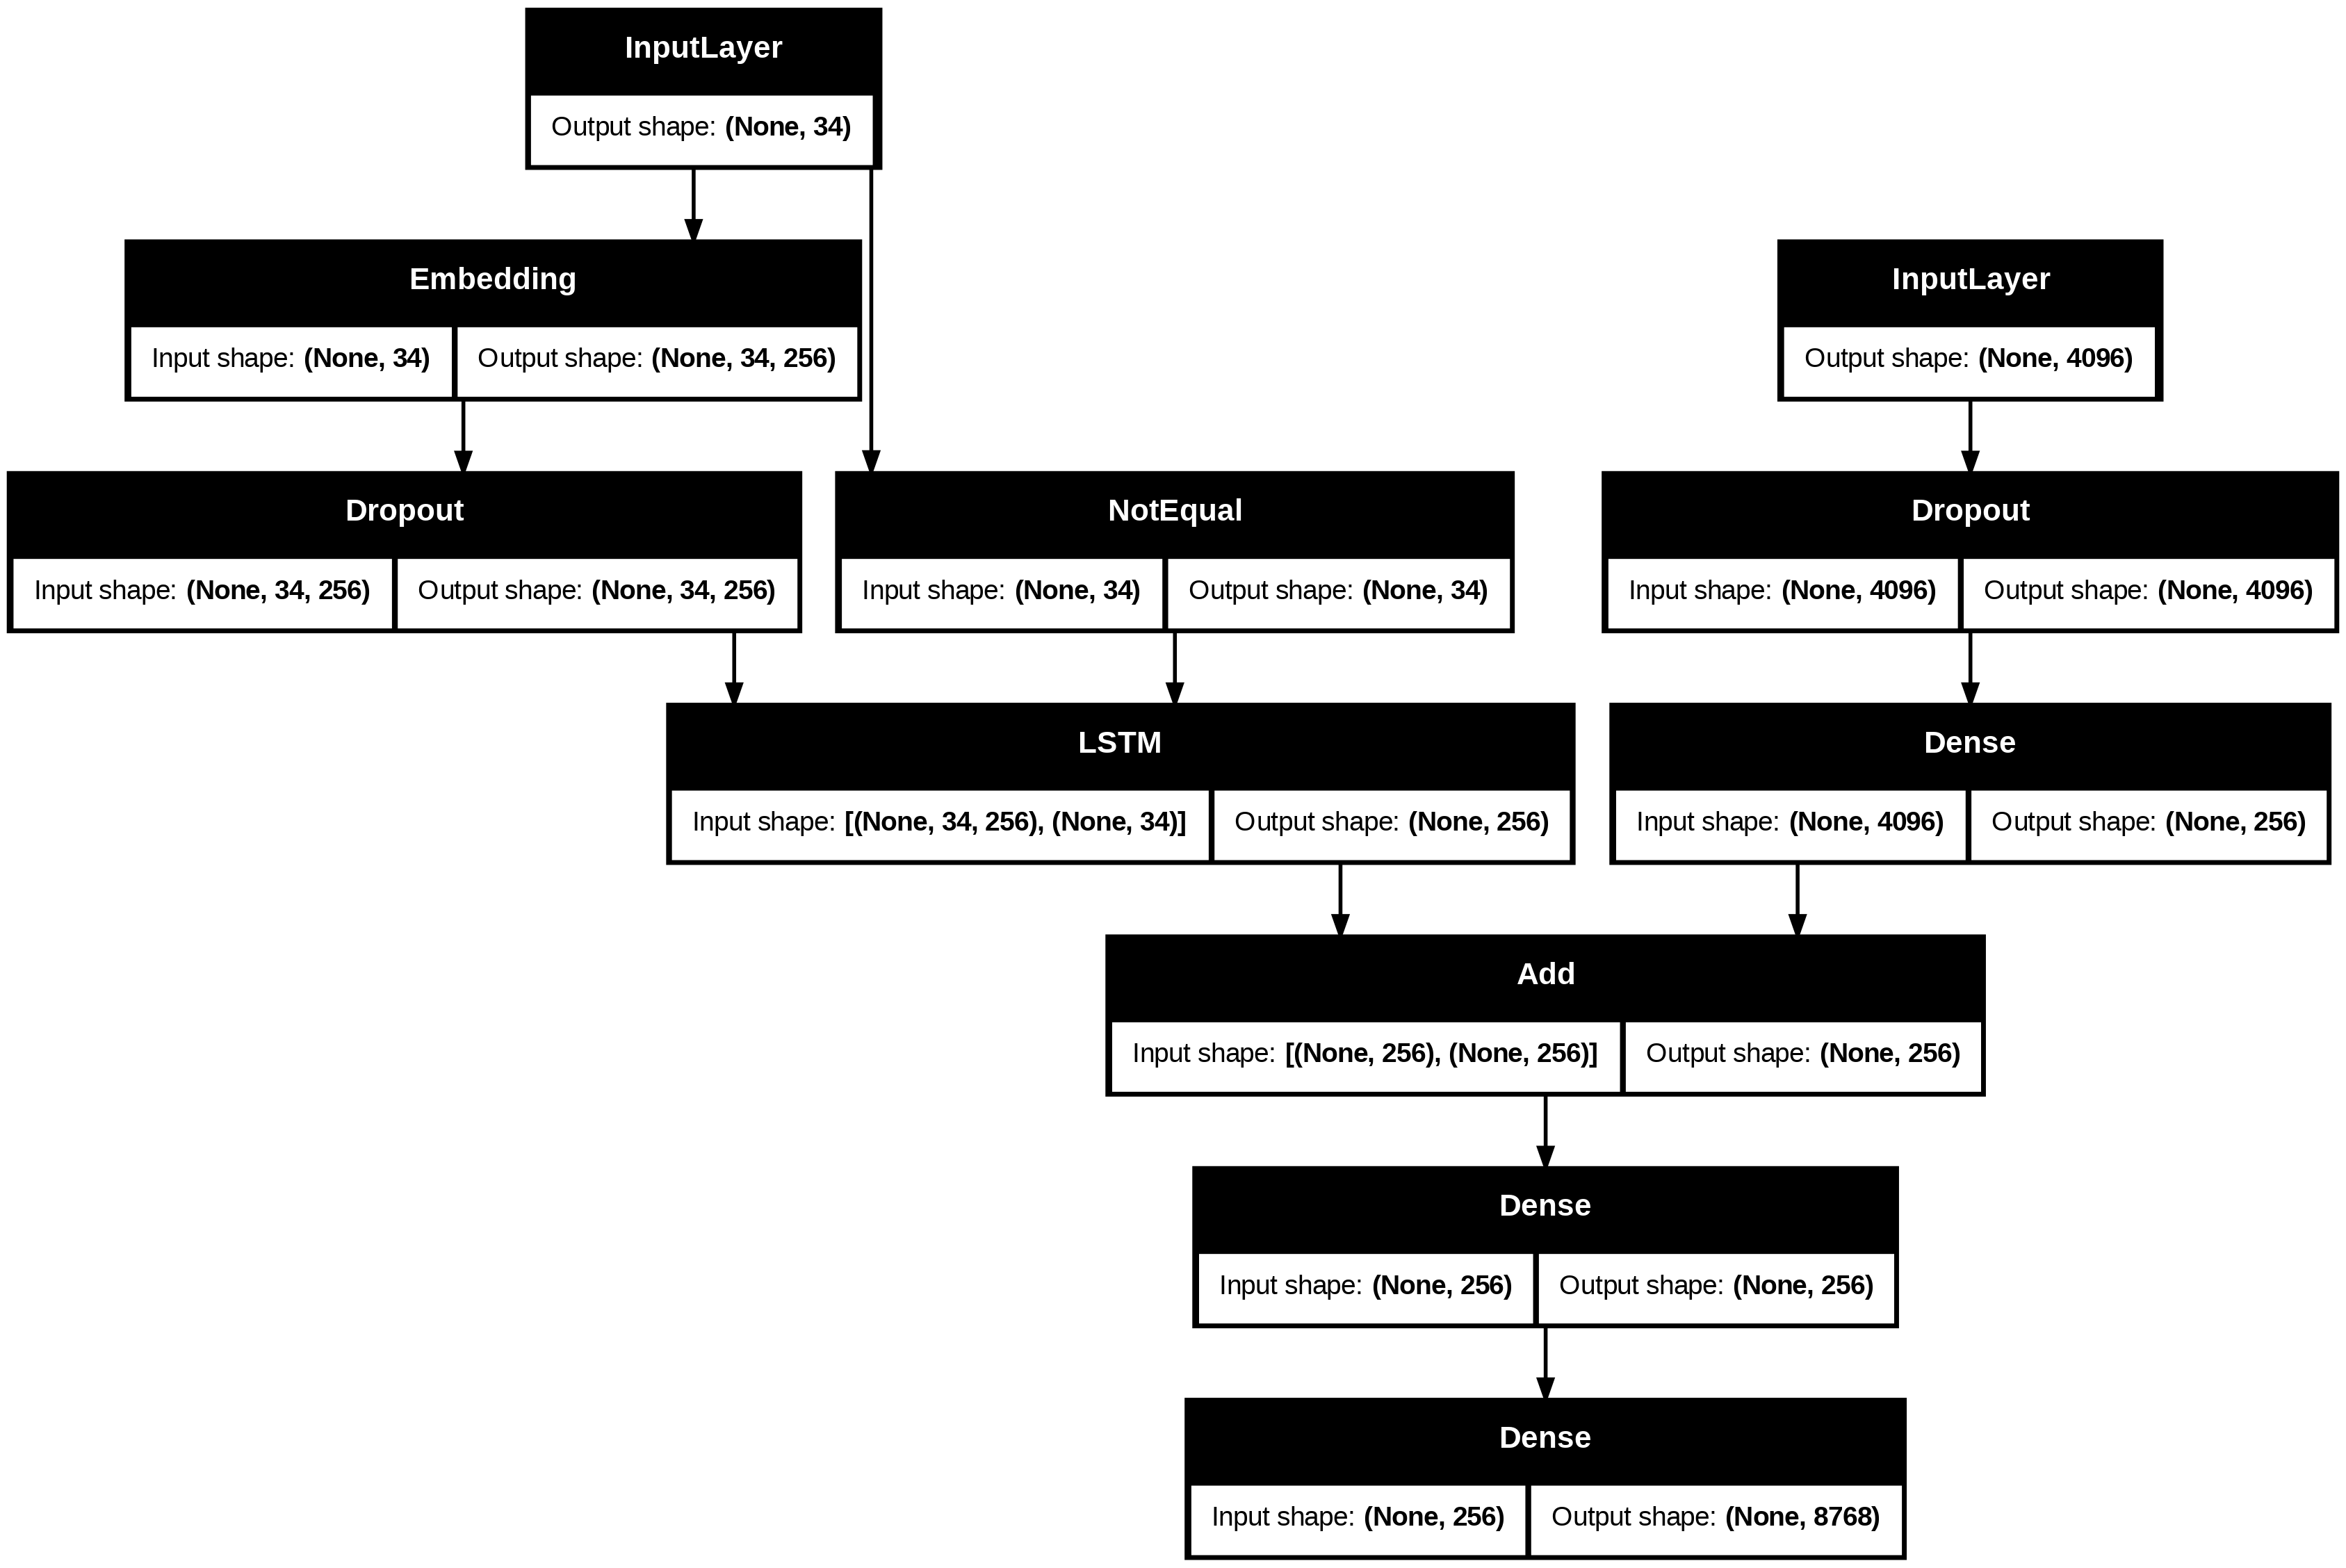

In [20]:
# encoder (image features)
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.4)(inputs1)
fe2 = Dense(256, activation='relu')(fe1)

# sequence model (text)
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se2 = Dropout(0.4)(se1)
se3 = LSTM(256)(se2)

# decoder (combine both)
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)
model.compile(loss='categorical_crossentropy', optimizer='adam')

# visualize
plot_model(model, show_shapes=True)

## Training the model 

In [21]:
epochs = 15
batch_size = 64
steps = len(train) // batch_size

for i in range(epochs):
    generator = data_generator(train, mapping, features, tokenizer, max_length, vocab_size, batch_size)
    
    model.fit(
        generator,
        epochs=1,
        steps_per_epoch=steps,
        verbose=1
    )

113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 6.9466
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.1214
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.6902
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.4775
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 4.0010
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.6049
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.5151
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3570
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 3.1791
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9528
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.8149
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.6863
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5480
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4372
113/113 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.1860


In [22]:
model.save(WORKING_DIR + '/best_model.keras')

## Generating captions for the image 

In [23]:
def idx_to_word(integer, tokenizer):
    return tokenizer.index_word.get(integer, None)

In [24]:


def predict_caption(model, image, tokenizer, max_length):
    
    in_text = 'startseq'
    
    for i in range(max_length):
        
        # convert text → sequence
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        
        # padding (IMPORTANT FIX)
        sequence = pad_sequences([sequence], maxlen=max_length, padding='post')
        
        # predict next word
        yhat = model.predict([image, sequence], verbose=0)
        yhat = np.argmax(yhat)
        
        # fast index → word
        word = tokenizer.index_word.get(yhat)
        
        if word is None:
            break
        
        # append word
        in_text += " " + word
        
        # stop condition
        if word == 'endseq':
            break
    
    # remove start and end tokens
    final_caption = in_text.replace('startseq', '').replace('endseq', '').strip()
    
    return final_caption

In [25]:
from nltk.translate.bleu_score import corpus_bleu

actual, predicted = list(), list()

for key in tqdm(test):
    captions = mapping[key]

    y_pred = predict_caption(model, features[key], tokenizer, max_length)

    actual_captions = [caption.split() for caption in captions]
    y_pred = y_pred.split()

    actual.append(actual_captions)
    predicted.append(y_pred)

# BLEU scores
print("BLEU-1:", corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2:", corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

  0%|          | 0/810 [00:00<?, ?it/s]

BLEU-1: 0.22379814870110482
BLEU-2: 0.11236047214833668


## Visualizing the results 

In [26]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def generate_caption(image_name):
    
    # get image id
    image_id = image_name.split('.')[0]
    
    # image path
    img_path = os.path.join(BASE_DIR, "Images", image_name)
    
    # load image
    image = Image.open(img_path)
    
    # get actual captions
    captions = mapping[image_id]
    
    print("----------Actual----------")
    for caption in captions:
        print(caption)
    
    # predict caption
    y_pred = predict_caption(model, features[image_id], tokenizer, max_length)
    
    print("----------Predicted----------")
    print(y_pred)
    
    # display image
    plt.imshow(image)
    plt.axis('off')
    plt.title(y_pred)
    plt.show()

----------Actual----------
startseq child in pink dress is climbing up set of stairs in an entry way endseq
startseq girl going into wooden building endseq
startseq little girl climbing into wooden playhouse endseq
startseq little girl climbing the stairs to her playhouse endseq
startseq little girl in pink dress going into wooden cabin endseq
----------Predicted----------
girl going into wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden wooden


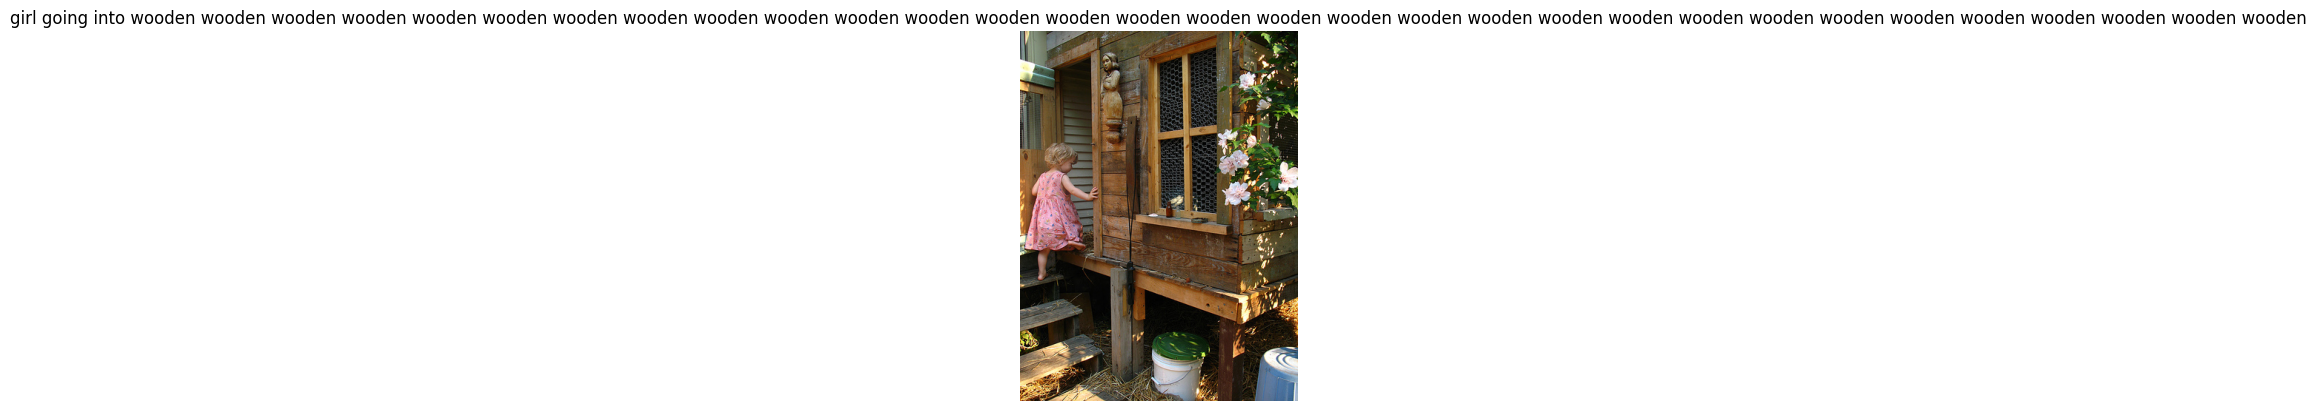

In [27]:
generate_caption('1000268201_693b08cb0e.jpg')

----------Actual----------
startseq man in brown shirt and dark shorts plays on the beach with his two black dogs endseq
startseq man in shorts with two black dogs holds ball throwing toy at the beach endseq
startseq man playing with two black dogs on the beach endseq
startseq man with two dogs on beach endseq
startseq man at the beach with two dogs endseq
----------Predicted----------
man with two shorts and two shorts and two shorts with two shorts with two shorts with two two shorts with two two two two two two two two two two two two two


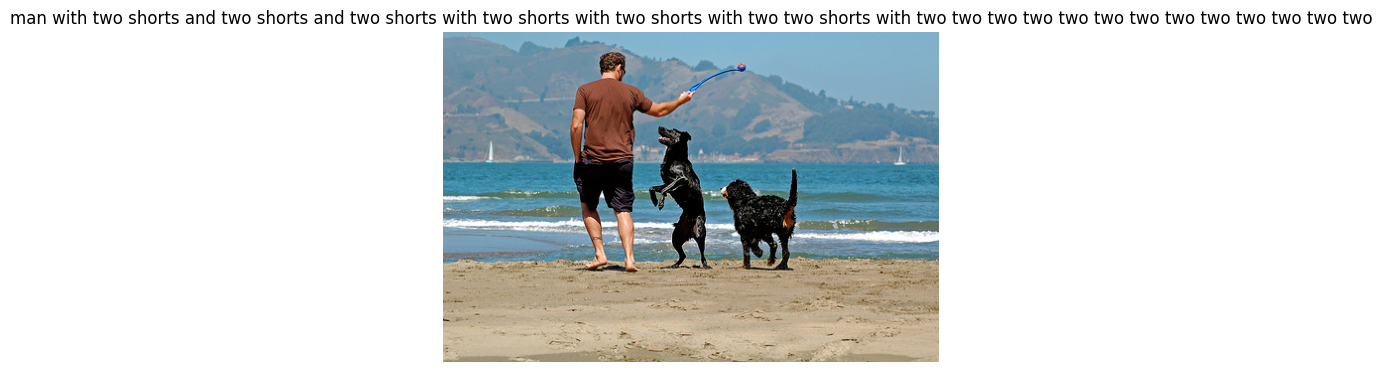

In [28]:
generate_caption('1075867198_27ca2e7efe.jpg')

----------Actual----------
startseq group of eight people are gathered around table at night endseq
startseq group of people gathered around in the dark endseq
startseq group of people sit around table outside on porch at night endseq
startseq group of people sit outdoors together at night endseq
startseq group of people sitting at table in darkened room endseq
----------Predicted----------
people of people gathered around table at table


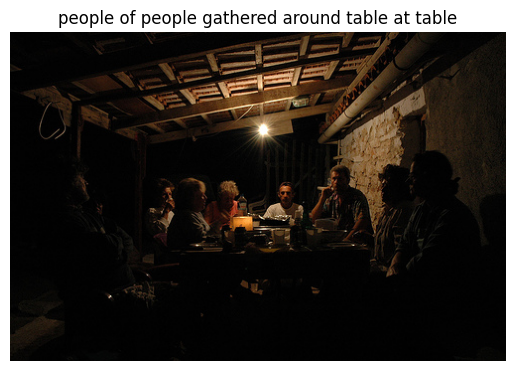

In [29]:
generate_caption('107582366_d86f2d3347.jpg')